In [35]:
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path
from scipy.spatial.distance import squareform

sc.set_figure_params(figsize=(5, 5))

In [36]:
adata = sc.read_h5ad("./heemskerk_data/adata_timeseries_old_48h-1_with_loop.h5ad")
meta = pd.read_csv("./heemskerk_data/MP_old_48-96h_new_D6-10_meta.csv", index_col=0)
adata.obs = meta.loc[adata.obs.index, :]

In [37]:
import inspect
import sys

sys.path.insert(0, "/home/stan/Git/micropattern/Bonsai-data-representation")
from bonsai.bonsai_dataprocessing import (
    get_bonsai_euclidean_distances,
)
from bonsai_scout.my_tree_layout import Layout_Tree
from paper_figure_scripts_and_notebooks.simulating_datasets.analyzing_simulated_datasets.knn_recall_helpers import (
    get_pdists_on_tree,
)

print(inspect.getsource(get_bonsai_euclidean_distances))
print(inspect.getsource(get_pdists_on_tree))

def get_bonsai_euclidean_distances(final_bonsai_folder, cell_ids):
    bonsai_ltqs_gc, _ = get_bonsai_posteriors(final_bonsai_folder, vert_ids=cell_ids)
    num_dims = bonsai_ltqs_gc.shape[0]
    bonsai_dists = distance.pdist(bonsai_ltqs_gc.T, metric='sqeuclidean') / num_dims
    return bonsai_dists

def get_pdists_on_tree(nwk_file, cell_ids):
    # Read in newick file
    tree = Layout_Tree()

    with open(nwk_file, "r") as f:
        nwk_str = f.readline()

    tree.from_newick(nwk_str=nwk_str)

    # Renumber vert_inds on tree such that they are in line with a depth-first search
    vertIndToNode, tree.nNodes = tree.root.renumber_verts(vertIndToNode={}, vert_count=0)
    tree.vert_ind_to_node = vertIndToNode
    tree.root.storeParent()

    # Get pairwise distances
    pdists = get_pairwise_dist_on_tree(tree, cell_ids)
    return pdists



In [38]:
# import some classes and functions
import pathlib

bonsai_output_folder = pathlib.Path(
    "/home/stan/Git/micropattern/notebooks/heemskerk_data/Bonsai_48h-1_hvg/final_bonsai"
)

# straight-line squared euclidean distances
euclidean_distances = squareform(
    get_bonsai_euclidean_distances(
        final_bonsai_folder=bonsai_output_folder,
        cell_ids=adata.obs.index,
    )
)

# tree distance
tree_distances = squareform(
    get_pdists_on_tree(
        nwk_file=bonsai_output_folder / "tree.nwk",
        cell_ids=adata.obs.index,
    )
)


# euclidean distances based on tree path
def get_pdists_on_tree_modified(nwk_file, cell_ids):
    # Read in newick file
    tree = Layout_Tree()

    with open(nwk_file, "r") as f:
        nwk_str = f.readline()

    tree.from_newick(nwk_str=nwk_str)

    # Renumber vert_inds on tree such that they are in line with a depth-first search
    vertIndToNode, tree.nNodes = tree.root.renumber_verts(
        vertIndToNode={}, vert_count=0
    )
    tree.vert_ind_to_node = vertIndToNode
    tree.root.storeParent()
    # replace tree distance with euclidean distance
    # same as get_pairwise_dist_on_tree with only weights replaced by squared euclidean distances
    node_id_to_vert_ind = {
        node.nodeId: vert_ind for vert_ind, node in tree.vert_ind_to_node.items()
    }
    indices = [node_id_to_vert_ind[node_id] for node_id in cell_ids]
    edge_dict = tree.get_edge_dict(nodeIdToVertInd=node_id_to_vert_ind)
    cols = edge_dict["source"]
    rows = edge_dict["target"]
    dist_mat = squareform(
        get_bonsai_euclidean_distances(
            bonsai_output_folder, list(node_id_to_vert_ind.keys())
        )
    )
    idx_lookup = {k: i for i, k in enumerate(node_id_to_vert_ind.keys())}
    weights = [dist_mat[idx_lookup[s], idx_lookup[t]] for s, t in zip(cols, rows)]
    cols = edge_dict["source_ind"]
    rows = edge_dict["target_ind"]

    colsComplete = np.concatenate((cols, rows))
    rowsComplete = np.concatenate((rows, cols))
    weightsComplete = np.concatenate((weights, weights))
    nVerts = np.max(colsComplete) + 1
    distance_csr = csr_matrix(
        (weightsComplete, (rowsComplete, colsComplete)), shape=(nVerts, nVerts)
    )

    print("Done preparing inputs. Starting shortest-path algorithm from Scipy.")
    distances = squareform(
        shortest_path(
            distance_csr,
            method="auto",
            directed=False,
            return_predecessors=False,
            unweighted=False,
            overwrite=False,
            indices=indices,
        )[:, indices],
        checks=False,
    )
    return distances


# squared euclidean distances based on tree path
euclidean_distances_tree = squareform(
    get_pdists_on_tree_modified(
        nwk_file=bonsai_output_folder / "tree.nwk", cell_ids=adata.obs.index
    )
)

Done preparing inputs. Starting shortest-path algorithm from Scipy.
Done preparing inputs. Starting shortest-path algorithm from Scipy.


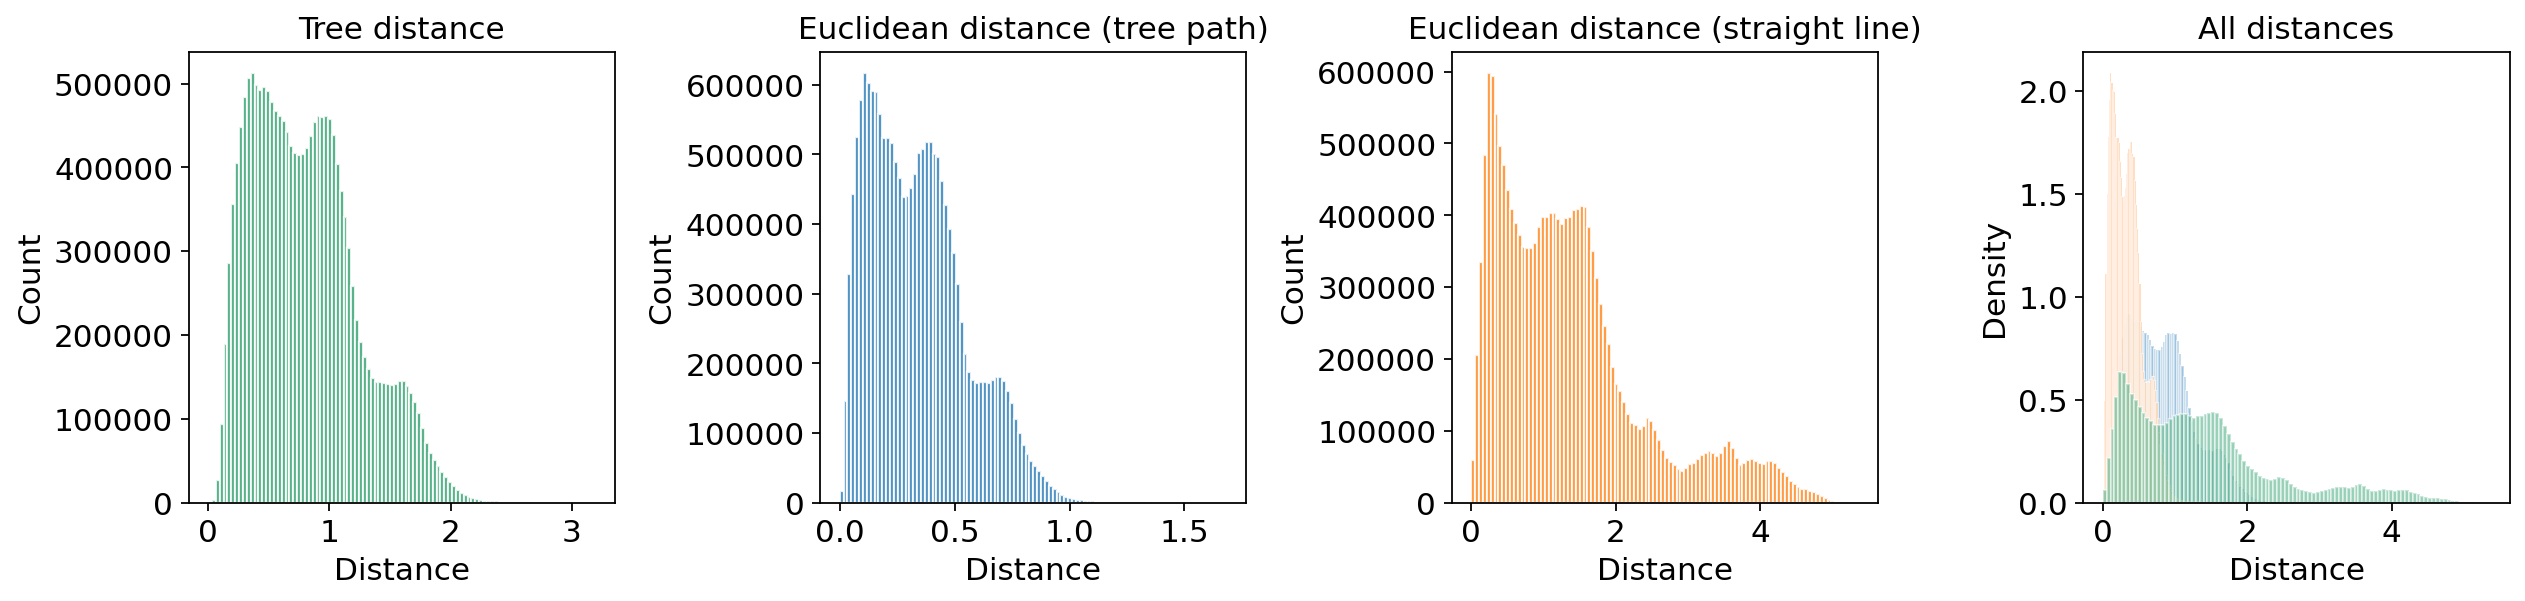

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].hist(
    squareform(tree_distances), bins=100, color="C2", alpha=0.85, edgecolor="white"
)
axes[0].set_title("Tree distance")
axes[0].set_xlabel("Distance")
axes[0].set_ylabel("Count")
axes[0].grid(False)

axes[1].hist(
    squareform(euclidean_distances_tree),
    bins=100,
    color="C0",
    alpha=0.85,
    edgecolor="white",
)
axes[1].set_title("Euclidean distance (tree path)")
axes[1].set_xlabel("Distance")
axes[1].set_ylabel("Count")
axes[1].grid(False)

axes[2].hist(
    squareform(euclidean_distances), bins=100, color="C1", alpha=0.85, edgecolor="white"
)
axes[2].set_title("Euclidean distance (straight line)")
axes[2].set_xlabel("Distance")
axes[2].set_ylabel("Count")
axes[2].grid(False)

axes[3].hist(
    squareform(tree_distances),
    bins=100,
    color="C0",
    alpha=0.5,
    edgecolor="white",
    density=True,
)
axes[3].hist(
    squareform(euclidean_distances_tree),
    bins=100,
    color="C1",
    alpha=0.5,
    edgecolor="white",
    density=True,
)
axes[3].hist(
    squareform(euclidean_distances),
    bins=100,
    color="C2",
    alpha=0.5,
    edgecolor="white",
    density=True,
)
axes[3].set_title("All distances")
axes[3].set_xlabel("Distance")
axes[3].set_ylabel("Density")
axes[3].grid(False)

plt.tight_layout()
plt.show()
plt.close()

In [41]:
# do quantile based matching to tree distance
lo_pct, up_pct = 0.05, 0.95
tree_distances_quantiles = np.quantile(squareform(tree_distances), [lo_pct, up_pct])
euclidean_distances_quantiles = np.quantile(
    squareform(euclidean_distances), [lo_pct, up_pct]
)
euclidean_distances_quantiles_tree = np.quantile(
    squareform(euclidean_distances_tree), [lo_pct, up_pct]
)

# stretch euclidean distances to tree distance range
euclidean_distances_match = squareform(
    np.maximum(
        (squareform(euclidean_distances) - euclidean_distances_quantiles[0])
        / (euclidean_distances_quantiles[1] - euclidean_distances_quantiles[0])
        * (tree_distances_quantiles[1] - tree_distances_quantiles[0])
        + tree_distances_quantiles[0],
        0,
    )
)
euclidean_distances_match_tree = squareform(
    np.maximum(
        (squareform(euclidean_distances_tree) - euclidean_distances_quantiles_tree[0])
        / (
            euclidean_distances_quantiles_tree[1]
            - euclidean_distances_quantiles_tree[0]
        )
        * (tree_distances_quantiles[1] - tree_distances_quantiles[0])
        + tree_distances_quantiles[0],
        0,
    )
)

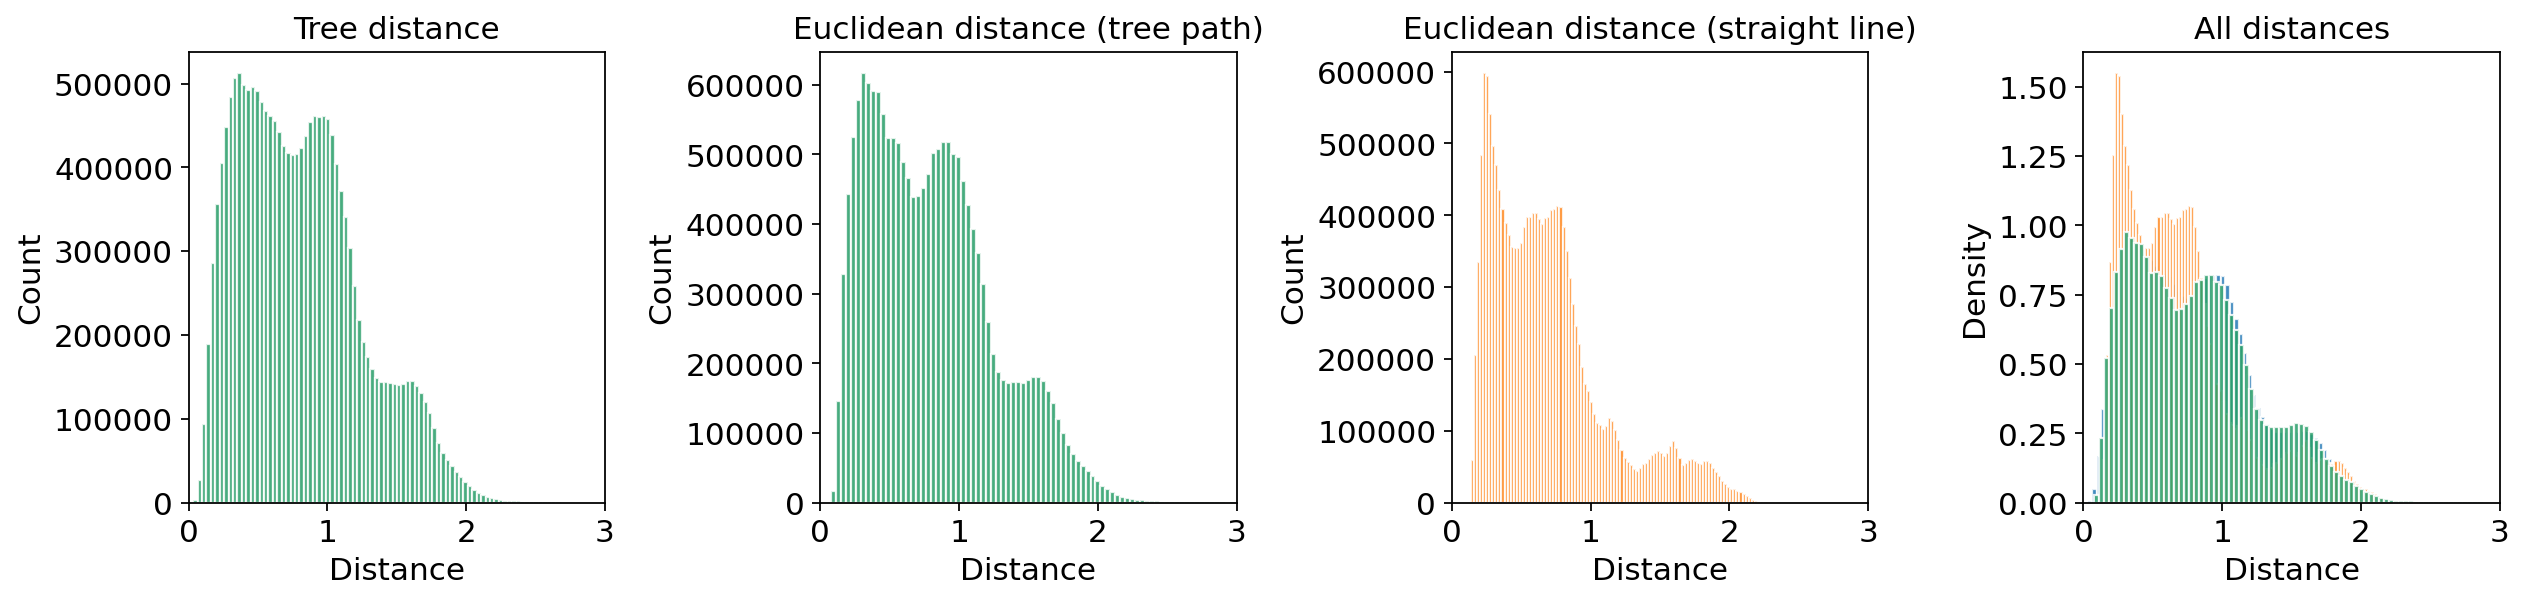

In [45]:
# recheck distributions
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].hist(
    squareform(tree_distances), bins=100, color="C2", alpha=0.85, edgecolor="white"
)
axes[0].set_title("Tree distance")
axes[0].set_xlabel("Distance")
axes[0].set_ylabel("Count")
axes[0].grid(False)

axes[1].hist(
    squareform(euclidean_distances_match_tree),
    bins=100,
    color="C2",
    alpha=0.85,
    edgecolor="white",
)
axes[1].set_title("Euclidean distance (tree path)")
axes[1].set_xlabel("Distance")
axes[1].set_ylabel("Count")
axes[1].grid(False)

axes[2].hist(
    squareform(euclidean_distances_match),
    bins=100,
    color="C1",
    alpha=0.85,
    edgecolor="white",
)
axes[2].set_title("Euclidean distance (straight line)")
axes[2].set_xlabel("Distance")
axes[2].set_ylabel("Count")
axes[2].grid(False)

axes[3].hist(
    squareform(tree_distances),
    bins=100,
    color="C0",
    alpha=0.85,
    edgecolor="white",
    density=True,
)
axes[3].hist(
    squareform(euclidean_distances_match),
    bins=100,
    color="C1",
    alpha=0.85,
    edgecolor="white",
    density=True,
)
axes[3].hist(
    squareform(euclidean_distances_match_tree),
    bins=100,
    color="C2",
    alpha=0.85,
    edgecolor="white",
    density=True,
)
axes[3].set_title("All distances")
axes[3].set_xlabel("Distance")
axes[3].set_ylabel("Density")
axes[3].grid(False)

for ax in axes:
    ax.set_xlim([0, 3])

plt.tight_layout()
plt.show()
plt.close()